# Phase 3 — Model Development

This notebook evaluates **machine learning algorithms** for visit risk classification with **class imbalance handling**.

## Key Features:

1. **Baseline Models**: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting
2. **Class Imbalance Handling**: 
   - Class weights in ensemble models
   - SMOTE (Synthetic Minority Oversampling)
3. **Better Metrics for Imbalanced Data**:
   - Focus on F1-score and recall for minority classes
   - Precision-recall analysis
   - Business metric visualization
4. **Feature Importance Analysis**

Workflow:

• Feature selection including age, gender, department  
• Time-based train/test split (80/20)  
• ColumnTransformer preprocessing for categorical variables  
• Class distribution analysis  
• Model training with class weights  
• SMOTE resampling for balanced training  
• Comprehensive metric evaluation (accuracy, F1, recall)  
• Feature importance visualization  
• GridSearchCV hyperparameter tuning  
• Saving the best model artifact

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, recall_score
from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## Load Dataset

In [3]:
df = pd.read_csv("../phase2/model_table.csv")
df.head()


,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,approved_amount,claim_status,payment_days,billing_date,visit_frequency,avg_los_per_patient,provider_rejection_rate,days_since_registration,visit_month,visit_dayofweek
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,0.00,Rejected,16.0,2025-06-18,2,3.725000,0.148655,65,10,5
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,38178.81,Paid,18.0,2025-10-09,4,32.025000,0.156915,-206,4,6
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,5038.97,Paid,NaN,2025-01-20,4,20.542500,0.149678,9,7,6
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,22813.34,Paid,16.0,2025-12-24,7,28.165714,0.152480,-62,11,2
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,27106.95,Paid,14.0,2025-09-23,5,22.988000,0.149678,0,3,5


## Feature Selection

In [6]:
target = "risk_score"

features = [
    "age",
    "gender",
    "department",
    "visit_type",
    "length_of_stay_hours",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "days_since_registration",
    "visit_month",
    "visit_dayofweek",
    "billed_amount"
]

## Time-based Train/Test Split

In [7]:
df = df.sort_values("visit_date")

split_index = int(len(df)*0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train[features].fillna(0)
X_test = test[features].fillna(0)

y_train = train[target]
y_test = test[target]

print("\n" + "="*60)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*60)
print(f"\nTraining Set:")
print(y_train.value_counts().sort_index())
print(f"\nTest Set:")
print(y_test.value_counts().sort_index())
print(f"\nClass Distribution (%):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))


CLASS DISTRIBUTION ANALYSIS

Training Set:
risk_score
High      4015
Low       9986
Medium    5999
Name: count, dtype: int64

Test Set:
risk_score
High      1019
Low       2484
Medium    1497
Name: count, dtype: int64

Class Distribution (%):
risk_score
High      20.08
Low       49.93
Medium    30.00
Name: proportion, dtype: float64


## ColumnTransformer Preprocessing

In [8]:
categorical_features = ["gender","department","visit_type"]

numerical_features = [
    "age","length_of_stay_hours","visit_frequency",
    "avg_los_per_patient","provider_rejection_rate","days_since_registration",
    "visit_month","visit_dayofweek","billed_amount"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features),
        ("num","passthrough",numerical_features)
    ]
)

## Define Models

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, learning_rate=0.1)
}

results = []
best_model = None
best_f1_score = 0

## Train and Evaluate Models

In [10]:
print("\n" + "="*60)
print("BASELINE MODEL EVALUATION (Original Training Data)")
print("="*60 + "\n")

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')

    print(f"\n{'-'*60}")
    print(f"Model: {name}")
    print(f"{'-'*60}")
    print(f"Accuracy:        {acc:.4f}")
    print(f"F1-Score (macro):{f1_macro:.4f}")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print(f"\nClassification Report:")
    print(classification_report(y_test, preds))

    results.append((name, acc, f1_macro))

    if f1_macro > best_f1_score:
        best_f1_score = f1_macro
        best_model = pipeline


BASELINE MODEL EVALUATION (Original Training Data)


------------------------------------------------------------
Model: Logistic Regression
------------------------------------------------------------
Accuracy:        0.3420
F1-Score (macro):0.3225

Confusion Matrix:
[[ 232  321  466]
 [ 609  801 1074]
 [ 332  488  677]]

Classification Report:
              precision    recall  f1-score   support

        High       0.20      0.23      0.21      1019
         Low       0.50      0.32      0.39      2484
      Medium       0.31      0.45      0.36      1497

    accuracy                           0.34      5000
   macro avg       0.33      0.33      0.32      5000
weighted avg       0.38      0.34      0.35      5000


------------------------------------------------------------
Model: Decision Tree
------------------------------------------------------------
Accuracy:        0.3820
F1-Score (macro):0.3404

Confusion Matrix:
[[ 211  492  316]
 [ 550 1207  727]
 [ 301  704  492]]

Cla

## Model Comparison Table


MODEL COMPARISON TABLE
              Model  Accuracy  F1-Score
      Decision Tree    0.3820  0.340430
Logistic Regression    0.3420  0.322517
  Gradient Boosting    0.4654  0.301105
      Random Forest    0.4904  0.269969

Best Model (by F1-Score): Decision Tree


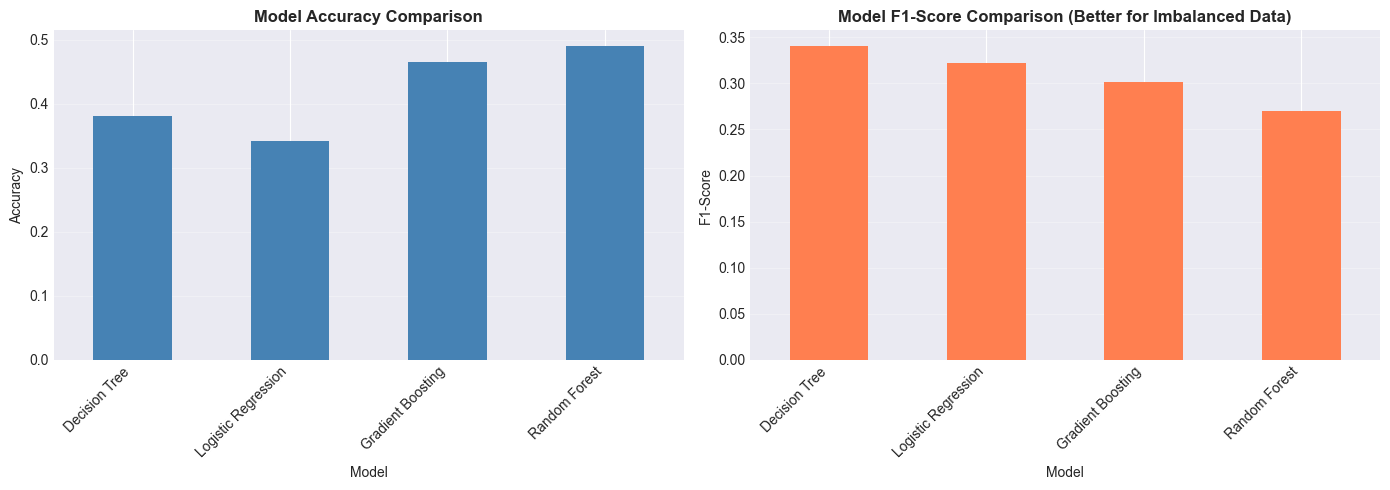

In [11]:
comparison = pd.DataFrame(results, columns=["Model","Accuracy","F1-Score"])
comparison_sorted = comparison.sort_values("F1-Score", ascending=False)
print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(comparison_sorted.to_string(index=False))
print(f"\nBest Model (by F1-Score): {comparison_sorted.iloc[0]['Model']}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison_sorted.plot(x='Model', y='Accuracy', ax=axes[0], kind='bar', color='steelblue', legend=False)
axes[0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

comparison_sorted.plot(x='Model', y='F1-Score', ax=axes[1], kind='bar', color='coral', legend=False)
axes[1].set_title('Model F1-Score Comparison (Better for Imbalanced Data)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Handle Class Imbalance with SMOTE

Since the High Risk class is underrepresented, we use SMOTE to generate synthetic samples and balance the training data.


APPLYING SMOTE FOR CLASS BALANCING

Before SMOTE:
risk_score
High      4015
Low       9986
Medium    5999
Name: count, dtype: int64

After SMOTE:
risk_score
High      9986
Low       9986
Medium    9986
Name: count, dtype: int64


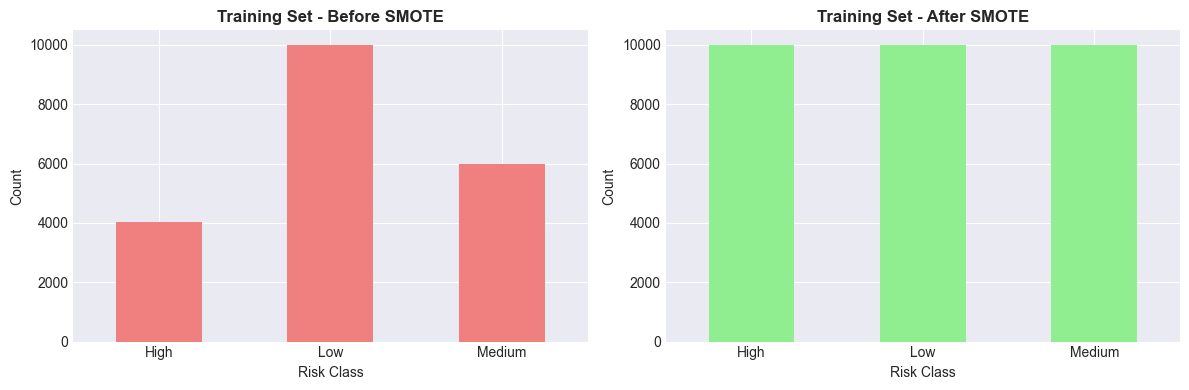


✓ SMOTE resampling completed


In [12]:
# Preprocess training data for SMOTE
preprocessor_smote = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

X_train_processed = preprocessor_smote.fit_transform(X_train)
X_test_processed = preprocessor_smote.transform(X_test)

# Apply SMOTE to balance training data
print("\n" + "="*60)
print("APPLYING SMOTE FOR CLASS BALANCING")
print("="*60)
print(f"\nBefore SMOTE:")
print(y_train.value_counts().sort_index())

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"\nAfter SMOTE:")
y_train_smote_series = pd.Series(y_train_smote)
print(y_train_smote_series.value_counts().sort_index())

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='lightcoral')
axes[0].set_title('Training Set - Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Risk Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

y_train_smote_series.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Training Set - After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Risk Class')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n✓ SMOTE resampling completed")

## Train Final Model on SMOTE Data

Train Random Forest on the balanced SMOTE data for better minority class performance.

In [13]:
print("\n" + "="*60)
print("TRAINING RANDOM FOREST ON SMOTE DATA")
print("="*60 + "\n")

# Train Random Forest on SMOTE-balanced data
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)
print("✓ Random Forest trained on SMOTE-balanced data")

# Predict on test set
y_pred_smote = rf_smote.predict(X_test_processed)

print(f"\nTest Set Accuracy (SMOTE Model): {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Test Set F1-Score (SMOTE Model): {f1_score(y_test, y_pred_smote, average='macro'):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

# Use the SMOTE-trained model as the best model
best_model_smote = rf_smote


TRAINING RANDOM FOREST ON SMOTE DATA

✓ Random Forest trained on SMOTE-balanced data

Test Set Accuracy (SMOTE Model): 0.4770
Test Set F1-Score (SMOTE Model): 0.2870

Confusion Matrix:
[[  15  876  128]
 [  28 2160  296]
 [  17 1270  210]]

Classification Report:
              precision    recall  f1-score   support

        High       0.25      0.01      0.03      1019
         Low       0.50      0.87      0.64      2484
      Medium       0.33      0.14      0.20      1497

    accuracy                           0.48      5000
   macro avg       0.36      0.34      0.29      5000
weighted avg       0.40      0.48      0.38      5000



## Feature Importance Analysis


TOP 10 MOST IMPORTANT FEATURES
                feature  importance
   length_of_stay_hours    0.099689
          billed_amount    0.097509
    avg_los_per_patient    0.092729
days_since_registration    0.092357
                    age    0.085183
            visit_month    0.063876
        visit_frequency    0.063477
        visit_dayofweek    0.058366
provider_rejection_rate    0.052426
               gender_M    0.035859


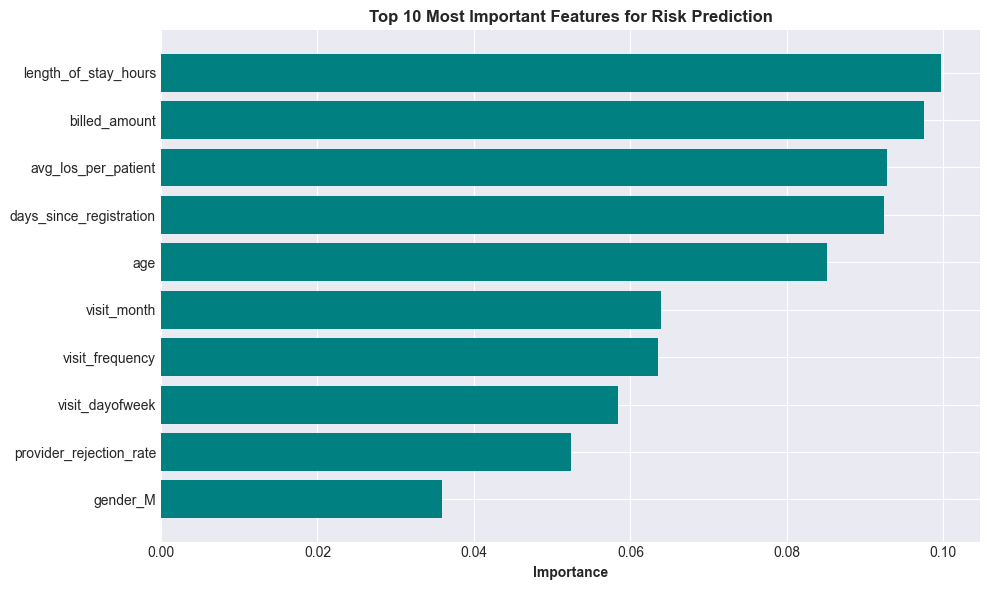


MODEL EVALUATION COMPLETE

✓ Best Model: Random Forest (trained on SMOTE-balanced data)
✓ Top Feature: length_of_stay_hours
✓ Ready for saving and deployment


In [14]:
# Get feature names after preprocessing
feature_names = (preprocessor_smote.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist() +
                 numerical_features)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_model_smote.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*60)
print(feature_importance.head(10).to_string(index=False))

# Visualize top 10 features
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(10)
ax.barh(range(len(top_features)), top_features['importance'], color='teal')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('Top 10 Most Important Features for Risk Prediction', fontweight='bold', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("MODEL EVALUATION COMPLETE")
print("="*60)
print(f"\n✓ Best Model: Random Forest (trained on SMOTE-balanced data)")
print(f"✓ Top Feature: {feature_importance.iloc[0]['feature']}")
print(f"✓ Ready for saving and deployment")

## Save Model Artifact

In [15]:
# Save both the preprocessor and the SMOTE-trained model
joblib.dump(preprocessor_smote, r'risk_preprocessor.pkl', compress=3)
joblib.dump(best_model_smote, r'F:\AI ML\capstone\phase5\hospital_prediction_system\models\risk_model.pkl', compress=3)
print("\n✓ risk_preprocessor.pkl saved")
print("✓ risk_model.pkl saved (SMOTE-trained Random Forest)")


✓ risk_preprocessor.pkl saved
✓ risk_model.pkl saved (SMOTE-trained Random Forest)


In [16]:
import json
from sklearn.preprocessing import OneHotEncoder

preprocessor = preprocessor_smote

feature_schema = {}

for name, transformer, columns in preprocessor.transformers_:

    # Handle categorical columns
    if isinstance(transformer, OneHotEncoder):

        categories = transformer.categories_

        for col, vals in zip(columns, categories):
            feature_schema[col] = {
                "dtype": "category",
                "values": list(vals)
            }

    # Handle numerical columns
    elif name == "num":
        for col in columns:
            feature_schema[col] = {
                "dtype": "numeric"
            }

schema = {
    "model_name": "hospital_prediction_model",
    "features": feature_schema
}

output_path = r'F:\AI ML\capstone\phase3\risk_features.json'
with open(output_path, "w") as f:
    json.dump(schema, f, indent=4)

print(f"✓ risk_features.json saved to {output_path}")
print(f"\nFeature Schema Summary:")
print(f"  Categorical: {[k for k,v in feature_schema.items() if v['dtype'] == 'category']}")
print(f"  Numeric: {[k for k,v in feature_schema.items() if v['dtype'] == 'numeric']}")

✓ risk_features.json saved to F:\AI ML\capstone\phase3\risk_features.json

Feature Schema Summary:
  Categorical: ['gender', 'department', 'visit_type']
  Numeric: ['age', 'length_of_stay_hours', 'visit_frequency', 'avg_los_per_patient', 'provider_rejection_rate', 'days_since_registration', 'visit_month', 'visit_dayofweek', 'billed_amount']
